# Extension Observation - Notebook Final

Ce notebook couvre uniquement l'extension `kinematics` vs `occupancy_grid`.

Objectifs:
- verifier la qualite des observations,
- executer un protocole d'entrainement/evaluation reproductible,
- analyser les ecarts entre representations.

In [18]:
import numpy as np
import pandas as pd
import matplotlib
from IPython import get_ipython
from IPython.display import display, Markdown

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

from common import seed_env
from observation_extension_config import build_config
from common_observation_extension import (
    EXT_ARTIFACTS_DIR,
    DEFAULT_EXTENSION_SETTINGS,
    make_extension_env,
    preprocess_observation,
)
from evaluate_observation_extension import evaluate_all as evaluate_observation_extension

print("Backend matplotlib:", matplotlib.get_backend())
print("Dossier artefacts extension:", EXT_ARTIFACTS_DIR)
EXT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

Backend matplotlib: inline
Dossier artefacts extension: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension


## 1. Verification des observations Occupancy Grid

Cette section verifie l'orientation, l'echelle et la forme des tenseurs avant entrainement.

Shape grille fine (C,H,W): (3, 22, 22)


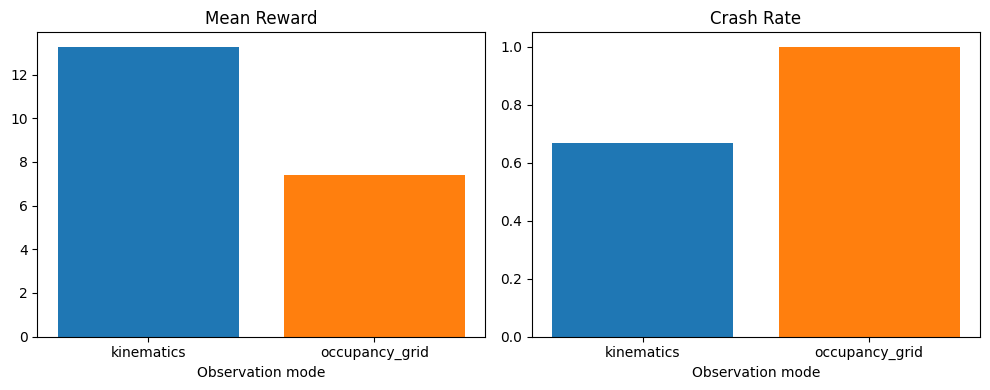

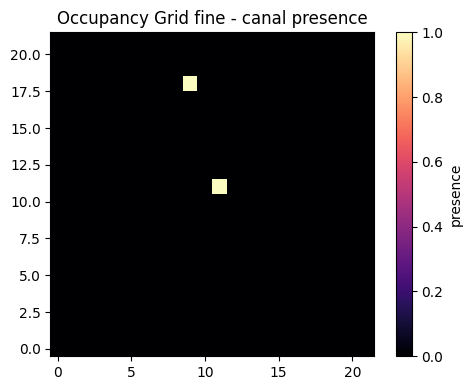

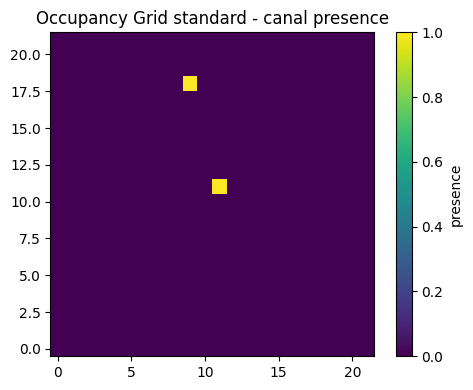

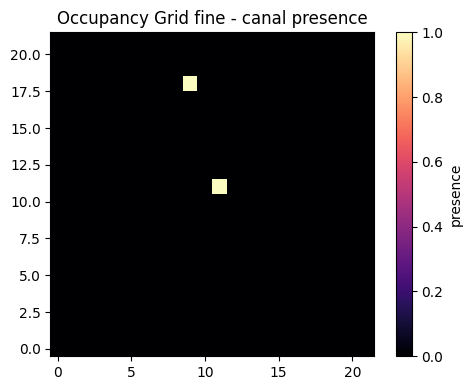

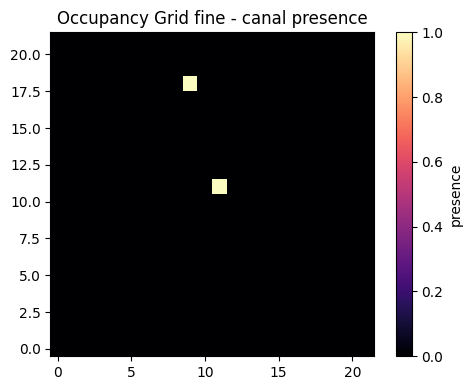

In [19]:
config_fine = build_config("occupancy_grid")
config_fine["observation"]["grid_step"] = [2.5, 2.5]
config_fine["observation"]["features"] = ["presence", "x", "y"]

fine_env = make_extension_env("occupancy_grid")
fine_env.unwrapped.configure(config_fine)
obs_fine, _ = seed_env(fine_env, 0)
processed_fine = preprocess_observation(obs_fine, "occupancy_grid")

print("Shape grille fine (C,H,W):", processed_fine.shape)

plt.figure(figsize=(5, 4))
plt.imshow(processed_fine[0], origin="lower", cmap="magma")
plt.colorbar(label="presence")
plt.title("Occupancy Grid fine - canal presence")
plt.tight_layout()
plt.show()

fine_env.close()

Shape brute: (3, 22, 22)
Shape preprocessee (C,H,W): (3, 22, 22)


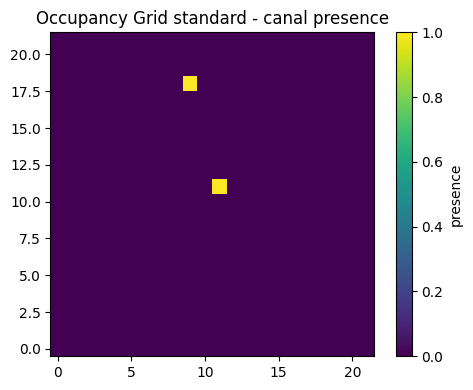

In [20]:
occupancy_env = make_extension_env("occupancy_grid")
obs, _ = seed_env(occupancy_env, 0)
processed = preprocess_observation(obs, "occupancy_grid")

print("Shape brute:", np.asarray(obs).shape)
print("Shape preprocessee (C,H,W):", processed.shape)

presence = processed[0]
plt.figure(figsize=(5, 4))
plt.imshow(presence, origin="lower", cmap="viridis")
plt.colorbar(label="presence")
plt.title("Occupancy Grid standard - canal presence")
plt.tight_layout()
plt.show()

occupancy_env.close()

## 2. Reevaluation des modeles existants (50 episodes)

Cette section reutilise les modeles deja presents dans `artifacts/observation_extension`.

Parametres utilises:
- seeds train: 0, 1, 2
- episodes eval: 50
- eval seeds: 4000 a 4049

In [ ]:
from pathlib import Path

ext_train_seeds = [0, 1, 2]
ext_eval_seeds = list(range(4000, 4050))

for mode in ["kinematics", "occupancy_grid"]:
    for seed in ext_train_seeds:
        model_path = EXT_ARTIFACTS_DIR / mode / f"seed_{seed}" / "checkpoints" / "final_model.pt"
        if not model_path.exists():
            raise FileNotFoundError(f"Modele introuvable: {model_path}")

print("Modeles trouves, lancement de l'evaluation 50 episodes")
ext_summary_df = evaluate_observation_extension(
    observation_modes=["kinematics", "occupancy_grid"],
    train_seeds=ext_train_seeds,
    eval_seeds=ext_eval_seeds,
    device="cpu",
)

display(ext_summary_df)

## 3. Analyse quantitative et graphiques (50 episodes)

In [ ]:
ext_csv = EXT_ARTIFACTS_DIR / "comparison_summary.csv"

if ext_csv.exists():
    ext_df = pd.read_csv(ext_csv).sort_values(["observation_mode", "train_seed"]).reset_index(drop=True)
    display(Markdown("### Resultats par run"))
    display(ext_df)

    metric_cols = [
        "mean_reward",
        "reward_std",
        "reward_median",
        "crash_rate",
        "mean_episode_length",
        "mean_speed",
    ]

    grouped_ext = ext_df.groupby("observation_mode")[metric_cols].agg(["mean", "std", "median"]).round(4)
    display(Markdown("### Agregation par mode"))
    display(grouped_ext)

    modes = set(ext_df["observation_mode"].unique())
    if {"kinematics", "occupancy_grid"}.issubset(modes):
        pivot_ext = ext_df.groupby("observation_mode")[metric_cols].mean()
        delta_ext = pd.DataFrame(index=metric_cols)
        delta_ext["occupancy_minus_kinematics"] = pivot_ext.loc["occupancy_grid"] - pivot_ext.loc["kinematics"]
        denom = pivot_ext.loc["kinematics"].replace(0, np.nan).abs()
        delta_ext["delta_relatif_pct"] = 100.0 * delta_ext["occupancy_minus_kinematics"] / denom
        display(Markdown("### Delta Occupancy Grid - Kinematics"))
        display(delta_ext.round(4))
else:
    print("Fichier introuvable:", ext_csv)

### Resultats par run

,observation_mode,train_seed,num_eval_episodes,mean_reward,reward_std,reward_median,crash_rate,mean_episode_length,mean_speed
0,kinematics,123,3,13.269452,8.269947,14.976262,0.666667,17.666667,23.085803
1,occupancy_grid,123,3,7.398408,1.806907,7.959012,1.000000,8.333333,28.506223


### Agregation par mode d'observation

mean_reward              reward_std              \
                        mean std   median       mean std  median   
observation_mode                                                   
kinematics           13.2695 NaN  13.2695     8.2699 NaN  8.2699   
occupancy_grid        7.3984 NaN   7.3984     1.8069 NaN  1.8069   

                 reward_median              crash_rate              \
                          mean std   median       mean std  median   
observation_mode                                                     
kinematics             14.9763 NaN  14.9763     0.6667 NaN  0.6667   
occupancy_grid          7.9590 NaN   7.9590     1.0000 NaN  1.0000   

                 mean_episode_length              mean_speed               
                                mean std   median       mean std   median  
observation_mode                                                           
kinematics                   17.6667 NaN  17.6667    23.0858 NaN  23.0858  
occupancy_grid                8.3333 NaN   8.3333    28.5062 NaN  28.5062

### Delta OccupancyGrid - Kinematics

,occupancy_minus_kinematics,delta_relatif_pct
mean_reward,-5.8710,-44.2448
reward_std,-6.4630,-78.1509
reward_median,-7.0172,-46.8558
crash_rate,0.3333,50.0000
mean_episode_length,-9.3333,-52.8302
mean_speed,5.4204,23.4795


In [ ]:
if ext_csv.exists():
    ext_df = pd.read_csv(ext_csv)

    agg = ext_df.groupby("observation_mode", as_index=False).agg(
        mean_reward=("mean_reward", "mean"),
        crash_rate=("crash_rate", "mean"),
        reward_seed_std=("mean_reward", "std"),
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(agg["observation_mode"], agg["mean_reward"], color=["#1f77b4", "#ff7f0e"])
    axes[0].set_title("Mean Reward par mode")
    axes[0].set_xlabel("Observation mode")

    axes[1].bar(agg["observation_mode"], agg["crash_rate"], color=["#1f77b4", "#ff7f0e"])
    axes[1].set_title("Crash Rate par mode")
    axes[1].set_xlabel("Observation mode")

    plt.tight_layout()
    summary_plot = EXT_ARTIFACTS_DIR / "observation_mode_summary_50eval.png"
    plt.savefig(summary_plot, dpi=180)
    plt.show()
    print("Figure enregistree:", summary_plot)

    all_episodes = []
    for mode in ["kinematics", "occupancy_grid"]:
        for seed in [0, 1, 2]:
            episode_path = EXT_ARTIFACTS_DIR / mode / f"seed_{seed}" / "evaluation" / "episodes.csv"
            if episode_path.exists():
                df_ep = pd.read_csv(episode_path)
                df_ep["observation_mode"] = mode
                df_ep["train_seed"] = seed
                all_episodes.append(df_ep)

    if all_episodes:
        episodes_df = pd.concat(all_episodes, ignore_index=True)

        rewards_by_mode = [
            episodes_df.loc[episodes_df["observation_mode"] == "kinematics", "reward"].values,
            episodes_df.loc[episodes_df["observation_mode"] == "occupancy_grid", "reward"].values,
        ]

        plt.figure(figsize=(7, 4))
        plt.boxplot(rewards_by_mode, labels=["kinematics", "occupancy_grid"])
        plt.title("Distribution des rewards (50 evals x 3 seeds)")
        plt.xlabel("Observation mode")
        plt.ylabel("Reward")
        plt.tight_layout()
        boxplot_path = EXT_ARTIFACTS_DIR / "reward_distribution_boxplot_50eval.png"
        plt.savefig(boxplot_path, dpi=180)
        plt.show()
        print("Figure enregistree:", boxplot_path)

        seed_curve = (
            episodes_df.groupby(["observation_mode", "episode_seed"], as_index=False)
            .agg(mean_reward=("reward", "mean"))
        )

        plt.figure(figsize=(9, 4))
        for mode in ["kinematics", "occupancy_grid"]:
            df_mode = seed_curve[seed_curve["observation_mode"] == mode].sort_values("episode_seed")
            plt.plot(df_mode["episode_seed"], df_mode["mean_reward"], label=mode)
        plt.title("Reward moyen par eval seed")
        plt.xlabel("Eval seed")
        plt.ylabel("Mean reward")
        plt.legend()
        plt.tight_layout()
        curve_path = EXT_ARTIFACTS_DIR / "reward_per_eval_seed_50eval.png"
        plt.savefig(curve_path, dpi=180)
        plt.show()
        print("Figure enregistree:", curve_path)

Figure enregistree: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\observation_mode_quick_compare.png


C:\Users\quent\AppData\Local\Temp\ipykernel_33924\3478875805.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Limites et interpretation

Points a retenir:
- `occupancy_grid` inclut un cout d'apprentissage plus eleve (CNN).
- la comparaison presentee repose sur 3 seeds et 30 episodes d'evaluation.
- une validation complementaire peut etre faite avec 100k-200k timesteps.

Lecture des metriques:
- `mean_reward`: plus eleve est preferable.
- `crash_rate`: plus faible est preferable.
- `reward_seed_std`: plus faible indique une meilleure stabilite inter-seeds.